### This notebook shows how the performance of the classification models was assessed in article "Bird Sounds Global - model builder: An end-to-end workflow for building locally fine-tuned bird classifiers"

In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from classifier import Classifier
from functions import top_preds
import os
import gc
import sys
import numpy as np
import shutil
from sklearn import metrics

/home/plauha/.conda/envs/birdnet/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Check results of model training

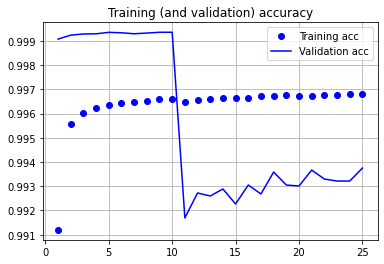

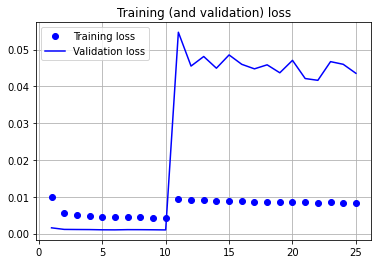

In [2]:
model_name = 'models/Spain_Portugal/'
rounds = 2 # in how many runs was the model trained

# visualize results of network training
def plot_results(history, val = True):
    acc = history['binary_accuracy']
    loss = history['loss']
    if val:
        val_acc = history['val_binary_accuracy']
        val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    if val:
        plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training (and validation) accuracy')
    plt.legend()
    plt.grid()
    plt.figure()
    plt.plot(epochs, loss, 'bo', label='Training loss')
    if val:
        plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training (and validation) loss')
    plt.legend()
    plt.grid()
    plt.show()

joint_history = {'loss':[], 'binary_accuracy':[], 'val_loss':[], 'val_binary_accuracy':[]}

for i in range(rounds):
    with open(model_name + 'training_history_' + str(i+1) + '.pkl', 'rb') as f:
        history = pickle.load(f)
        for stat in ['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy']:
            joint_history[stat] = joint_history[stat] + history[stat]

plot_results(joint_history)

# Analyze validation data

In [3]:
# analyze validation data with own model
model_version = 'model_v1.2.tflite'

class_list = pd.read_csv(model_name + 'classes.csv')
path_to_data = model_name + 'local_training_data/'
os.mkdir('validation_data')

with open(path_to_data + 'metadata/val_set.pkl', 'rb') as f:
    val_data = pickle.load(f)
with open(path_to_data + 'metadata/labels.pkl', 'rb') as f:
    labels = pickle.load(f)

val_data = [f for f in val_data if f[-11:]!='cleaned.wav'] # only analyze clips with original background 
for f in val_data:
    shutil.move(path_to_data + f, 'validation_data/' + f) 
    
cls = Classifier(path_to_model=model_name + model_version)
final_preds = np.zeros((len(val_data), len(class_list)))

for i in range(len(val_data)):
    pred, t = cls.classify('validation_data/' + val_data[i], max_pred=False)
    pred = pred[0,:] # select first 3 seconds
    
    with open('test_results.txt', 'a') as f:
        f.write(str(val_data[i]))
        for p in pred:
            f.write(',')
            f.write(str(p))
        f.write('\n')

test_results = pd.read_csv('test_results.txt', header=None)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Loading file validation_data/30931_5.0_144.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/30931_8.0_145.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/30229_5.0_1327.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/30229_8.0_1328.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29729_5.0_1507.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29729_8.0_1508.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/30892_5.0_2240.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/30892_8.0_2241.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29467_5.0_2590.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29467_8.0_2591.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/20272_5.0_264

Recording analyzed!
Loading file validation_data/29220_4.2_16949.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29376_3.2_16973.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29376_5.7_16975.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29376_10.4_16977.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29581_6.3_17020.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29581_11.9_17022.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29849_4.4_17094.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29849_8.0_17095.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29849_5.2_17097.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/29849_11.2_17098.wav...
Classifying recording...
Recording analyzed!
Loading

Recording analyzed!
Loading file validation_data/74022_9.6_22003.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74022_12.6_22005.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74022_6.3_22007.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74022_5.6_22008.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74022_10.2_22009.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74022_8.7_22010.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74022_3.2_22011.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74022_9.0_22012.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74317_11.0_22037.wav...
Classifying recording...
Recording analyzed!
Loading file validation_data/74504_5.1_22055.wav...
Classifying recording...
Recording analyzed!
Loading

In [4]:
# create a data frame of true labels

true_lab = pd.DataFrame(0, index=np.arange(len(val_data)), columns=list(range(len(class_list)+1)))
true_lab[0] = val_data

for i in range(len(true_lab)):
    true_lab.loc[i, 1:len(class_list)+1] = labels[true_lab[0].iloc[i]].astype(int)

true_lab.to_csv('true_labels.csv', index=False)    

In [5]:
# analyze with BirdNET-Analyzer by running following command on command line
# python3 analyze.py --i validation_data/ --o birdnet_results/ --min_conf 0.01


for f in test_results[0]:
    data = pd.read_csv('birdnet_results/' + f.replace('wav', 'BirdNET.selection.table.txt'), sep = '\t')
    filename = f
 
    with open('BN_test_results.txt', 'a') as f:
        f.write(filename)
        for sp_code in class_list['species_code']:
            f.write(',')
            conf = data['Confidence'].loc[data['Species Code']==sp_code]
            if len(conf)>0:
                f.write(str(conf.iloc[0]))
            else:
                f.write(str(0))
        f.write('\n')

bn_results = pd.read_csv('BN_test_results.txt', header=None)

In [6]:
# Calculate AUCs

ns = np.zeros(len(class_list)-2)

df = pd.DataFrame({'n':ns})

results = ['test_results.txt', 'BN_test_results.txt']
model = ['BSG', 'birdnet']

for k in range(2):
    aucs = np.zeros(len(class_list)-2)
    classes = np.zeros(len(class_list)-2)
    data=pd.read_csv(results[k], sep=',', header=None)
    
    for i in range(3,len(class_list)+1):
        classes[i-3] = i-1
        try:
            aucs[i-3] = metrics.roc_auc_score(true_lab[i], data[i])
            ns[i-3] = sum(true_lab[i]==1)
        except:
            print("Can not process class " + str(i))
    df['n']=ns
    df['class'] = classes
    df[model[k]] = aucs

df['model'] = model_name.split('/')[1]

df

Can not process class 5
Can not process class 7
Can not process class 8
Can not process class 9
Can not process class 10
Can not process class 12
Can not process class 13
Can not process class 15
Can not process class 16
Can not process class 17
Can not process class 18
Can not process class 20
Can not process class 21
Can not process class 22
Can not process class 23
Can not process class 24
Can not process class 25
Can not process class 26
Can not process class 27
Can not process class 30
Can not process class 31
Can not process class 33
Can not process class 34
Can not process class 35
Can not process class 37
Can not process class 38
Can not process class 39
Can not process class 40
Can not process class 41
Can not process class 44
Can not process class 45
Can not process class 46
Can not process class 47
Can not process class 50
Can not process class 52
Can not process class 54
Can not process class 55
Can not process class 56
Can not process class 57
Can not process class 58
Can 

NameError: name 'Spain_Portugal2' is not defined

In [10]:
# Show species with at least 5 positive test samples
df.loc[df['n']>5]

,n,class,BSG,birdnet,model
0,8.0,2.0,0.995787,0.867275,Spain_Portugal2
33,11.0,35.0,0.995844,0.860519,Spain_Portugal2
45,11.0,47.0,0.996364,0.951948,Spain_Portugal2
50,9.0,52.0,0.986190,0.881356,Spain_Portugal2
74,12.0,76.0,0.967433,0.784962,Spain_Portugal2
75,13.0,77.0,0.955091,0.726100,Spain_Portugal2
83,9.0,85.0,0.854991,0.591965,Spain_Portugal2
86,8.0,88.0,0.838483,0.613062,Spain_Portugal2
89,8.0,91.0,0.990169,0.935744,Spain_Portugal2


In [11]:
# add results to existing results from previous models
aucs = pd.read_csv('all_aucs.csv')
aucs = pd.concat([aucs, df])
aucs.to_csv('all_aucs.csv', index=False)

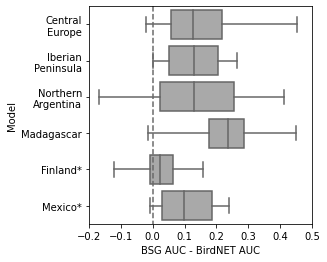

In [25]:
import seaborn as sns

plt.rcParams["figure.figsize"] = (4,4)

aucs = pd.read_csv('all_aucs.csv')
aucs['difference'] = aucs['BSG'] - aucs['birdnet']
aucs = aucs.loc[aucs['n']>4]
aucs = aucs.loc[aucs['birdnet']!=0.5] # exclude species not included in BirdNET 
aucs = aucs.loc[aucs['birdnet']!=0]

sns.boxplot(data=aucs, x='difference', y='model', whis = 2, order=['Central Europe', 'Iberian Peninsula', 'Northern Argentina', 'Madagascar', 'Finland*', 'Mexico*'], color='darkgrey')
plt.xlim(-0.2, 0.5)
plt.vlines(0, -0.5, len(np.unique(aucs['model']))-0.5, colors='dimgrey', linestyles='dashed')
#plt.title('Model comparison BSG - BirdNET')
plt.xlabel('BSG AUC - BirdNET AUC')
plt.ylabel('Model')
plt.yticks(ticks=range(len(np.unique(aucs['model']))), labels=['Central\nEurope', 'Iberian\nPeninsula', 'Northern\nArgentina', 'Madagascar', 'Finland*', 'Mexico*'])
#plt.xticks(rotation=340)

#plt.savefig('model_comparison.tiff', dpi = 600, format='tiff', bbox_inches='tight')
plt.savefig('model_comparison.svg', dpi=600, format='svg', bbox_inches='tight')
#plt.savefig('model_comparison.eps', format='eps', bbox_inches='tight')
plt.show()

In [17]:
# Print AUC comparison

aucs = pd.read_csv('all_aucs.csv')
aucs['difference'] = aucs['BSG'] - aucs['birdnet']
aucs = aucs.loc[aucs['n']>4]
aucs = aucs.loc[aucs['birdnet']==0.5] # AUCs for species not included in BirdNET 
print(f"BSG AUC (non-BirdNET species): {round(np.mean(aucs['BSG']),3)}") 

aucs = pd.read_csv('all_aucs.csv')
aucs['difference'] = aucs['BSG'] - aucs['birdnet']
aucs = aucs.loc[aucs['n']>4]
aucs = aucs.loc[aucs['birdnet']!=0.5] # AUCs for species included in BirdNET 
print(f"BSG AUC (BirdNET species): {round(np.mean(aucs['BSG']),3)}")
print(f"BirdNET AUC (BirdNET species): {round(np.mean(aucs['birdnet']),3)}")

BSG AUC (non-BirdNET species): 0.888
BSG AUC (BirdNET species): 0.904
BirdNET AUC (BirdNET species): 0.824


In [15]:
# print average AUCs per model

aucs = pd.read_csv('all_aucs.csv')
aucs = aucs.loc[aucs['n']>4]

print('BSG')
for m in np.unique(aucs['model']):
    print(f"{m}: {round(np.mean(aucs['BSG'].loc[aucs['model']==m]),3)}, (n={len(aucs.loc[aucs['model']==m])})")
    
aucs = pd.read_csv('all_aucs.csv')
aucs = aucs.loc[aucs['n']>4]
aucs = aucs.loc[aucs['birdnet']!=0.5]

print('BirdNET')
for m in np.unique(aucs['model']):
    print(f"{m}: {round(np.mean(aucs['birdnet'].loc[aucs['model']==m]),3)}, (n={len(aucs.loc[aucs['model']==m])})")

BSG
Argentina (Chaco): 0.929, (n=11)
Central Europe: 0.972, (n=42)
Finland*: 0.888, (n=206)
Iberian Peninsula: 0.957, (n=11)
Madagascar: 0.887, (n=64)
Mexico*: 0.93, (n=24)
BirdNET
Argentina (Chaco): 0.789, (n=10)
Central Europe: 0.825, (n=42)
Finland*: 0.863, (n=206)
Iberian Peninsula: 0.828, (n=11)
Madagascar: 0.662, (n=48)
Mexico*: 0.823, (n=24)


In [2]:
# Calculate p-values for difference between BSG / BirdNET AUCs

from scipy import stats

aucs = pd.read_csv('all_aucs.csv')
aucs = aucs.loc[aucs['n']>4]
aucs = aucs.loc[aucs['birdnet']!=0.5]
models = np.unique(aucs['model'])

m = models[0]
for m in models:
    print(f"{m}: p-value:{round(stats.ttest_rel(aucs['BSG'].loc[aucs['model']==m], aucs['birdnet'].loc[aucs['model']==m]).pvalue, 5)}")

Central Europe: p-value:0.0
Finland*: p-value:0.0
Iberian Peninsula: p-value:0.00064
Madagascar: p-value:0.0
Mexico*: p-value:0.0
Northern Argentina: p-value:0.03341
